In [1]:
import itertools, math, random, time
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from IPython.display import display
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, confusion_matrix, r2_score

SEED = 13
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
torch.set_num_threads(min(4, max(1, torch.get_num_threads())))
device = torch.device("cpu")
np.set_printoptions(precision=3, suppress=True)
print("device:", device, "seed:", SEED)


device: cpu seed: 13


## 1. Configuration

In [2]:

# data
N = 300
L = 90
p = 40
A = D = 3
K_DATA = 2

I_CONDITIONS = np.array([
    [0,0,0], [1,0,0], [0,1,0], [0,0,1]
], dtype=np.float32)

# observation model
OBS_NONLINEAR_STRENGTH = 0.10
OBS_NOISE_SD = 0.03

# one-stage representation update
MAX_OUTER = 32
LR_REP = 4e-4
LR_MILESTONES = [10, 20, 28]  # absolute, independent of MAX_OUTER
LR_GAMMA = 0.25
RECON_SIGMA = 0.20
BETA_ID = 1.0
BETA_DYN = 0.008

# v111 mechanism / graph score
RIDGE = 1e-3
VAL_FRAC = 0.25
LAMBDA_LAG_SCORE = 0.001
LAMBDA_INST_SCORE = 0.001

# mixture
RESP_TEMP = 1.0
PI_ALPHA = 1.0
RESP_FLOOR = 1e-4
MIN_EFFECTIVE_N = 12.0
DEAD_PATIENCE = 3

# direct particle movement
GRAPH_MOVES_PER_OUTER = 3
TAU_GRAPH = 4e-4
ETA_H = 0.65
TAU_H = 0.60
TAU_LOGVAR = 0.02

# convergence
MIN_CONVERGENCE_ITER = 25
CONVERGENCE_PATIENCE = 4
Z_REL_TOL = 2e-5
RESP_REL_TOL = 2e-4
H_REL_TOL = 3e-4

print({
    "K_DATA": K_DATA, "MAX_OUTER": MAX_OUTER,
    "TAU_GRAPH": TAU_GRAPH, "TAU_H": TAU_H
})


{'K_DATA': 2, 'MAX_OUTER': 32, 'TAU_GRAPH': 0.0004, 'TAU_H': 0.6}


## 2. Two-regime latent temporal simulation

In [3]:

def adj_from_edges(edges, d=A):
    G = np.zeros((d,d), dtype=np.float32)
    for u,v in edges:
        G[u,v] = 1.0
    return G

def is_dag(G):
    G = (G > .5).astype(int)
    indeg = G.sum(0).astype(int).tolist()
    q = [j for j in range(len(G)) if indeg[j] == 0]
    seen = 0
    while q:
        u = q.pop(0); seen += 1
        for v in range(len(G)):
            if G[u,v]:
                indeg[v] -= 1
                if indeg[v] == 0: q.append(v)
    return seen == len(G)

def topo_order(G):
    G = (G > .5).astype(int)
    indeg = G.sum(0).astype(int).tolist()
    q = [j for j in range(len(G)) if indeg[j] == 0]
    out = []
    while q:
        u = q.pop(0); out.append(u)
        for v in range(len(G)):
            if G[u,v]:
                indeg[v] -= 1
                if indeg[v] == 0: q.append(v)
    if len(out) != len(G): raise ValueError("not DAG")
    return out

TRUE_LAG = [
    adj_from_edges([(0,1),(0,2),(1,2)]),
    adj_from_edges([(2,1),(2,0),(1,0)]),
]
TRUE_INST = [
    adj_from_edges([(0,1),(1,2)]),
    adj_from_edges([(2,1),(1,0)]),
]

TRUE_PI = np.array([0.55, 0.45])

true_bias = [
    np.array([0.45,-0.40,0.30], np.float32),
    np.array([-0.45,0.40,-0.30], np.float32),
]
true_self = [
    np.array([0.55,0.45,0.50], np.float32),
    np.array([0.48,0.52,0.42], np.float32),
]
true_lag_coef = [np.zeros((A,A),np.float32) for _ in range(K_DATA)]
true_inst_coef = [np.zeros((A,A),np.float32) for _ in range(K_DATA)]
true_lag_coef[0][0,1]=.80; true_lag_coef[0][0,2]=-.60; true_lag_coef[0][1,2]=.70
true_inst_coef[0][0,1]=.65; true_inst_coef[0][1,2]=-.55
true_lag_coef[1][2,1]=-.75; true_lag_coef[1][2,0]=.65; true_lag_coef[1][1,0]=-.70
true_inst_coef[1][2,1]=.60; true_inst_coef[1][1,0]=.55

true_noise_sd = [
    np.array([.20,.20,.20],np.float32),
    np.array([.22,.19,.21],np.float32),
]
true_int_mean = np.array([-2.0,2.0,-1.5],np.float32)
true_int_sd = np.array([.30,.30,.30],np.float32)

rng_sim = np.random.default_rng(SEED)
R_true = rng_sim.choice(K_DATA, size=N, p=TRUE_PI)
I_index = rng_sim.integers(0, len(I_CONDITIONS), size=N)
I_np = I_CONDITIONS[I_index].astype(np.float32)

Z_true_np = np.zeros((N,L,A),np.float32)
Z_true_np[:,0] = rng_sim.normal(size=(N,A)).astype(np.float32)

for i in range(N):
    r = int(R_true[i])
    order = topo_order(TRUE_INST[r])
    for t in range(1,L):
        prev = Z_true_np[i,t-1]
        curr = np.zeros(A,np.float32)
        for a in order:
            if I_np[i,a] > .5:
                curr[a] = rng_sim.normal(true_int_mean[a], true_int_sd[a])
            else:
                mu = true_bias[r][a] + true_self[r][a]*prev[a]
                for k in range(A):
                    if TRUE_LAG[r][k,a] > .5:
                        mu += true_lag_coef[r][k,a]*np.tanh(prev[k])
                    if TRUE_INST[r][k,a] > .5:
                        mu += true_inst_coef[r][k,a]*np.tanh(curr[k])
                curr[a] = rng_sim.normal(mu, true_noise_sd[r][a])
        Z_true_np[i,t] = curr

print("regime counts:", np.bincount(R_true))
for r in range(K_DATA):
    print(f"regime {r+1} lag\n", TRUE_LAG[r].astype(int))
    print(f"regime {r+1} inst\n", TRUE_INST[r].astype(int))


regime counts: [168 132]
regime 1 lag
 [[0 1 1]
 [0 0 1]
 [0 0 0]]
regime 1 inst
 [[0 1 0]
 [0 0 1]
 [0 0 0]]
regime 2 lag
 [[0 0 0]
 [1 0 0]
 [1 1 0]]
regime 2 inst
 [[0 0 0]
 [1 0 0]
 [0 1 0]]


## 3. Shared observation model and train/validation split

In [4]:

rng_obs = np.random.default_rng(SEED+200)
B_linear = rng_obs.normal(size=(A,p)).astype(np.float32)
U,_,Vt = np.linalg.svd(B_linear, full_matrices=False)
B_linear = (2.0*(U@Vt)).astype(np.float32)
W_nonlin = rng_obs.normal(0,.8,size=(A,24)).astype(np.float32)
B_nonlin = rng_obs.normal(0,1/np.sqrt(24),size=(24,p)).astype(np.float32)

Y_np = (
    Z_true_np@B_linear
    + OBS_NONLINEAR_STRENGTH*(np.tanh(Z_true_np@W_nonlin)@B_nonlin)
    + rng_obs.normal(0,OBS_NOISE_SD,size=(N,L,p)).astype(np.float32)
)
ym = Y_np.reshape(-1,p).mean(0,keepdims=True)
ys = Y_np.reshape(-1,p).std(0,keepdims=True)+1e-6
Y_np = ((Y_np-ym)/ys).astype(np.float32)

rng_split = np.random.default_rng(SEED+11)
idx = np.arange(N); rng_split.shuffle(idx)
n_val = int(round(VAL_FRAC*N))
val_idx, train_idx = idx[:n_val], idx[n_val:]

Y = torch.tensor(Y_np,dtype=torch.float32,device=device)
I_torch = torch.tensor(I_np,dtype=torch.float32,device=device)
print("Y",Y_np.shape,"train/val",len(train_idx),len(val_idx))


Y (300, 90, 40) train/val 225 75


## 4. Encoder, decoder, and coordinate identification

In [5]:

class LinearPCAEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        pca = PCA(n_components=D,random_state=SEED).fit(Y_np[train_idx].reshape(-1,p))
        self.linear = nn.Linear(p,D)
        with torch.no_grad():
            self.linear.weight.copy_(torch.tensor(pca.components_,dtype=torch.float32))
            self.linear.bias.copy_(torch.tensor(-pca.mean_@pca.components_.T,dtype=torch.float32))
    def forward(self,y): return self.linear(y)

class ResidualDecoder(nn.Module):
    def __init__(self,encoder):
        super().__init__()
        self.base=nn.Linear(D,p)
        with torch.no_grad():
            yf=Y_np[train_idx].reshape(-1,p)
            xf=encoder(torch.tensor(yf,dtype=torch.float32)).numpy()
            Xd=np.c_[xf,np.ones(len(xf))]
            b=np.linalg.lstsq(Xd,yf,rcond=None)[0]
            self.base.weight.copy_(torch.tensor(b[:-1].T,dtype=torch.float32))
            self.base.bias.copy_(torch.tensor(b[-1],dtype=torch.float32))
        self.res=nn.Sequential(nn.Linear(D,32),nn.SiLU(),nn.Linear(32,32),nn.SiLU(),nn.Linear(32,p))
        nn.init.zeros_(self.res[-1].weight); nn.init.zeros_(self.res[-1].bias)
    def forward(self,x): return self.base(x)+.10*self.res(x)

def init_models():
    torch.manual_seed(SEED)
    enc=LinearPCAEncoder().to(device); dec=ResidualDecoder(enc).to(device)
    opt=torch.optim.AdamW(list(enc.parameters())+list(dec.parameters()),lr=LR_REP,weight_decay=1e-6)
    sch=torch.optim.lr_scheduler.MultiStepLR(opt,milestones=LR_MILESTONES,gamma=LR_GAMMA)
    return enc,dec,opt,sch

def encode_all_np(enc):
    enc.eval()
    with torch.no_grad():
        X=enc(Y.reshape(-1,p)).reshape(N,L,D).cpu().numpy().astype(np.float64)
    enc.train(); return X

def whitening_from_training(X):
    v=X[train_idx].reshape(-1,D); m=v.mean(0)
    C=np.cov(v-m,rowvar=False)+1e-6*np.eye(D)
    e,V=np.linalg.eigh(C); Q=V@np.diag(1/np.sqrt(e))@V.T
    return m,Q

def mechanism_break_update(Xw,Wprev=None):
    rows=[]
    for a in range(A):
        active=train_idx[I_np[train_idx,a]>.5]
        cur=Xw[active,1:].reshape(-1,D); pre=Xw[active,:-1].reshape(-1,D)
        cur-=cur.mean(0); pre-=pre.mean(0)
        C=cur.T@pre/max(len(cur)-1,1)
        U,_,_=np.linalg.svd(C,full_matrices=True)
        w=U[:,-1]
        if Wprev is not None and np.dot(w,Wprev[a])<0: w=-w
        rows.append(w)
    W=np.stack(rows); W/=np.linalg.norm(W,axis=1,keepdims=True)+1e-12
    return W

def transform_all(X,Wprev=None):
    xm,Q=whitening_from_training(X); Xw=(X-xm)@Q
    W=mechanism_break_update(Xw,Wprev)
    Zraw=Xw@W.T
    base=train_idx[I_np[train_idx].sum(1)==0]
    zm=Zraw[base].reshape(-1,A).mean(0)
    zs=Zraw[base].reshape(-1,A).std(0)+1e-8
    return dict(X=X,Xw=Xw,xm=xm,Q=Q,W=W,zm=zm,zs=zs,Z=(Zraw-zm)/zs)


## 5. Enumerated joint graph state space

In [6]:

def enumerate_lag():
    edges=[(i,j) for i in range(A) for j in range(A) if i!=j]
    out=[]
    for bits in itertools.product([0,1],repeat=len(edges)):
        G=np.zeros((A,A),np.float32)
        for b,e in zip(bits,edges): G[e]=b
        out.append(G)
    return out

def enumerate_inst():
    edges=[(i,j) for i in range(A) for j in range(A) if i!=j]
    out=[]
    for bits in itertools.product([0,1],repeat=len(edges)):
        G=np.zeros((A,A),np.float32)
        for b,e in zip(bits,edges): G[e]=b
        if is_dag(G): out.append(G)
    return out

LAG_GRAPHS=enumerate_lag(); INST_GRAPHS=enumerate_inst()
GRAPH_PAIRS=[]; PAIR_LOOKUP={}
for Gl in LAG_GRAPHS:
    for Gi in INST_GRAPHS:
        j=len(GRAPH_PAIRS); GRAPH_PAIRS.append((Gl.copy(),Gi.copy()))
        PAIR_LOOKUP[(Gl.astype(np.int8).tobytes(),Gi.astype(np.int8).tobytes())]=j

def ptuple(G,a): return tuple(np.where(G[:,a]>.5)[0].tolist())
def pair_index(Gl,Gi): return PAIR_LOOKUP[(Gl.astype(np.int8).tobytes(),Gi.astype(np.int8).tobytes())]

def neighbors(j):
    Gl,Gi=GRAPH_PAIRS[j]; out={j}
    for u in range(A):
        for v in range(A):
            if u==v: continue
            x=Gl.copy(); x[u,v]=1-x[u,v]; out.add(pair_index(x,Gi))
            x=Gi.copy(); x[u,v]=1-x[u,v]
            if is_dag(x): out.add(pair_index(Gl,x))
            if Gi[u,v]>.5:
                x=Gi.copy(); x[u,v]=0; x[v,u]=1
                if is_dag(x): out.add(pair_index(Gl,x))
    return np.array(sorted(out),int)

GRAPH_NEIGHBORS=[neighbors(j) for j in range(len(GRAPH_PAIRS))]
TRUE_PAIR_INDEX=[pair_index(TRUE_LAG[r],TRUE_INST[r]) for r in range(K_DATA)]
print("graph pairs:",len(GRAPH_PAIRS),"true indices:",TRUE_PAIR_INDEX)


graph pairs: 1600 true indices: [1321, 282]


## 6. Responsibility-weighted v111 mechanism fitting and scoring

In [7]:

def local_design(zp,zc,lp,ip,a):
    cols=[np.ones(len(zp)),zp[:,a]]
    cols += [np.tanh(zp[:,k]) for k in lp]
    cols += [np.tanh(zc[:,k]) for k in ip]
    return np.stack(cols,1)

def weighted_ridge(Xd,y,w):
    w=np.clip(w,1e-8,None)
    XtW=Xd.T*w
    P=XtW@Xd+RIDGE*np.eye(Xd.shape[1])
    b=np.linalg.solve(P,XtW@y)
    res=y-Xd@b
    var=float(np.clip(np.sum(w*res**2)/np.sum(w),.05**2,2.0**2))
    cov=var*np.linalg.inv(P)
    return b,var,cov

def fit_component_cache(Z,gamma_col):
    cache={}
    for split_name,ids in [("tr",train_idx),("va",val_idx)]:
        pass
    zp_tr=Z[train_idx,:-1].reshape(-1,A); zc_tr=Z[train_idx,1:].reshape(-1,A)
    it_tr=np.repeat(I_np[train_idx],L-1,axis=0)
    wt_tr=np.repeat(gamma_col[train_idx],L-1)
    zp_va=Z[val_idx,:-1].reshape(-1,A); zc_va=Z[val_idx,1:].reshape(-1,A)
    it_va=np.repeat(I_np[val_idx],L-1,axis=0)
    wt_va=np.repeat(gamma_col[val_idx],L-1)

    for a in range(A):
        other=[k for k in range(A) if k!=a]
        for lb in itertools.product([0,1],repeat=len(other)):
            lp=tuple(k for k,b in zip(other,lb) if b)
            for ib in itertools.product([0,1],repeat=len(other)):
                ip=tuple(k for k,b in zip(other,ib) if b)
                obs=it_tr[:,a]<.5
                Xd=local_design(zp_tr[obs],zc_tr[obs],lp,ip,a)
                y=zc_tr[obs,a]; w=wt_tr[obs]
                beta,var,cov=weighted_ridge(Xd,y,w)
                ints=~obs; yi=zc_tr[ints,a]; wi=wt_tr[ints]
                im=float(np.sum(wi*yi)/(np.sum(wi)+1e-12))
                iv=float(np.clip(np.sum(wi*(yi-im)**2)/(np.sum(wi)+1e-12),.05**2,2.0**2))

                obv=it_va[:,a]<.5
                Xv=local_design(zp_va[obv],zc_va[obv],lp,ip,a)
                yv=zc_va[obv,a]; wv=wt_va[obv]
                ll=-.5*(np.log(2*np.pi*var)+(yv-Xv@beta)**2/var)
                inv=~obv; yvi=zc_va[inv,a]; wvi=wt_va[inv]
                lli=-.5*(np.log(2*np.pi*iv)+(yvi-im)**2/iv)
                total=float(np.sum(wv*ll)+np.sum(wvi*lli))
                den=float(np.sum(wv)+np.sum(wvi)+1e-12)
                cache[(a,lp,ip)]=dict(avg_ll=total/den,beta=beta,beta_cov=cov,
                    obs_var=var,int_mean=im,int_var=iv,n_int=max(float(np.sum(wi)),1.0),
                    lag_parents=lp,inst_parents=ip)
    return cache

def score_pairs(cache):
    s=np.empty(len(GRAPH_PAIRS))
    for j,(Gl,Gi) in enumerate(GRAPH_PAIRS):
        ll=np.mean([cache[(a,ptuple(Gl,a),ptuple(Gi,a))]["avg_ll"] for a in range(A)])
        s[j]=ll-LAMBDA_LAG_SCORE*Gl.sum()-LAMBDA_INST_SCORE*Gi.sum()
    return s

def H_for_pair(cache,j):
    Gl,Gi=GRAPH_PAIRS[j]
    return [deepcopy(cache[(a,ptuple(Gl,a),ptuple(Gi,a))]) for a in range(A)]

CANON=2+2*A
def canonicalize(fit,a):
    out=np.zeros(CANON); out[:2]=fit["beta"][:2]; pos=2
    for k in fit["lag_parents"]: out[2+k]=fit["beta"][pos]; pos+=1
    for k in fit["inst_parents"]: out[2+A+k]=fit["beta"][pos]; pos+=1
    return out

def perturb_H(fit,a,r,noise):
    b=canonicalize(fit,a)
    # diagonal approximation in canonical coordinates
    sd=np.zeros(CANON)
    diag=np.sqrt(np.clip(np.diag(fit["beta_cov"]),0,None))
    sd[:2]=diag[:2]; pos=2
    for k in fit["lag_parents"]: sd[2+k]=diag[pos]; pos+=1
    for k in fit["inst_parents"]: sd[2+A+k]=diag[pos]; pos+=1
    return dict(
        beta_full=b+np.sqrt(TAU_H)*sd*noise["H"][r,a],
        obs_var=float(np.clip(fit["obs_var"]*np.exp(TAU_LOGVAR*noise["lv"][r,a]),.05**2,2**2)),
        int_mean=float(fit["int_mean"]+np.sqrt(TAU_H*fit["int_var"]/fit["n_int"])*noise["im"][r,a]),
        int_var=float(np.clip(fit["int_var"]*np.exp(TAU_LOGVAR*noise["ilv"][r,a]),.05**2,2**2))
    )

def blend_H(old,target):
    if old is None: return deepcopy(target)
    return dict(
        beta_full=(1-ETA_H)*old["beta_full"]+ETA_H*target["beta_full"],
        obs_var=float(np.exp((1-ETA_H)*np.log(old["obs_var"])+ETA_H*np.log(target["obs_var"]))),
        int_mean=float((1-ETA_H)*old["int_mean"]+ETA_H*target["int_mean"]),
        int_var=float(np.exp((1-ETA_H)*np.log(old["int_var"])+ETA_H*np.log(target["int_var"])))
    )


## 7. Trajectory likelihoods, responsibilities, and mixture initialization

In [8]:

def trajectory_loglik(Z,j,H):
    Gl,Gi=GRAPH_PAIRS[int(j)]
    out=np.zeros(N)
    zp=Z[:,:-1]; zc=Z[:,1:]
    for a in range(A):
        h=H[a]
        pred=h["beta_full"][0]+h["beta_full"][1]*zp[:,:,a]
        for k in range(A):
            pred += h["beta_full"][2+k]*Gl[k,a]*np.tanh(zp[:,:,k])
            pred += h["beta_full"][2+A+k]*Gi[k,a]*np.tanh(zc[:,:,k])
        obs=I_np[:,a]<.5
        ll_obs=-.5*(np.log(2*np.pi*h["obs_var"])+(zc[:,:,a]-pred)**2/h["obs_var"])
        ll_int=-.5*(np.log(2*np.pi*h["int_var"])+(zc[:,:,a]-h["int_mean"])**2/h["int_var"])
        out += np.where(obs[:,None],ll_obs,ll_int).sum(1)/(L-1)
    return out/A

def update_responsibilities(Z,pairs,Hs,pi):
    LL=np.stack([trajectory_loglik(Z,pairs[r],Hs[r]) for r in range(len(pairs))],1)
    logits=np.log(np.clip(pi,1e-12,None))[None,:]+LL/RESP_TEMP
    logits-=logits.max(1,keepdims=True)
    g=np.exp(logits); g/=g.sum(1,keepdims=True)
    g=np.maximum(g,RESP_FLOOR); g/=g.sum(1,keepdims=True)
    return g,LL

def trajectory_features(Z):
    # Rich summaries: means, scales, lag cross-covariance and contemporaneous covariance.
    rows=[]
    for i in range(len(Z)):
        zp=Z[i,:-1]; zc=Z[i,1:]
        zp0=zp-zp.mean(0); zc0=zc-zc.mean(0)
        lag=(zc0.T@zp0)/max(len(zp)-1,1)
        cov=(zc0.T@zc0)/max(len(zc)-1,1)
        rows.append(np.r_[Z[i].mean(0),Z[i].std(0),lag.ravel(),cov[np.triu_indices(A)]])
    F=np.asarray(rows)
    return (F-F.mean(0))/(F.std(0)+1e-6)

def initialize_mixture(Z,k_fit,noise):
    # Discover the two data regimes first; extra fitted components are initialized
    # as duplicate splits of these base groups rather than artificial new regimes.
    base=KMeans(n_clusters=K_DATA,random_state=SEED,n_init=50).fit(
        trajectory_features(Z)
    ).labels_
    gamma=np.full((N,k_fit),RESP_FLOOR)
    for q in range(K_DATA):
        comps=[r for r in range(k_fit) if r % K_DATA == q]
        mask=(base==q)
        gamma[np.ix_(mask,comps)] = 1.0/len(comps)
    gamma/=gamma.sum(1,keepdims=True)
    pi=gamma.mean(0)
    pairs=[]; Hs=[]; caches=[]
    for r in range(k_fit):
        c=fit_component_cache(Z,gamma[:,r]); s=score_pairs(c)
        j=int(np.argmax(s)); pairs.append(j); caches.append(c)
        Hs.append([perturb_H(f,a,r,noise) for a,f in enumerate(H_for_pair(c,j))])
    return gamma,pi,np.array(pairs,int),Hs,caches

def fixed_noise(k_fit):
    rng=np.random.default_rng(SEED+900+k_fit)
    return dict(
        graph=rng.gumbel(size=(k_fit,len(GRAPH_PAIRS))),
        H=rng.normal(size=(k_fit,A,CANON)),
        lv=rng.normal(size=(k_fit,A)),
        im=rng.normal(size=(k_fit,A)),
        ilv=rng.normal(size=(k_fit,A)),
    )


## 8. Differentiable one-stage representation loss

In [9]:

def torch_transform(x,state):
    xm=torch.tensor(state["xm"],dtype=x.dtype); Q=torch.tensor(state["Q"],dtype=x.dtype)
    W=torch.tensor(state["W"].T,dtype=x.dtype); zm=torch.tensor(state["zm"],dtype=x.dtype)
    zs=torch.tensor(state["zs"],dtype=x.dtype)
    Xw=(x-xm)@Q; Z=(Xw@W-zm)/zs
    return Z,Xw

def id_loss(Xw,Ibatch,Wnp):
    W=torch.tensor(Wnp,dtype=Xw.dtype)
    vals=[]
    for a in range(A):
        active=Ibatch[:,a]>.5
        def cc(mask):
            c=Xw[mask,1:].reshape(-1,D); p0=Xw[mask,:-1].reshape(-1,D)
            c=c-c.mean(0); p0=p0-p0.mean(0)
            return c.T@p0/max(c.shape[0]-1,1)
        Ci=cc(active); Co=cc(~active)
        vals.append(torch.sum((W[a]@Ci)**2)/(torch.sum((W[a]@Co)**2)+1e-6))
    return torch.stack(vals).mean()

def mixture_dyn_nll(z,Ibatch,pairs,Hs,gamma_batch):
    losses=[]
    for r in range(len(pairs)):
        Gl=torch.tensor(GRAPH_PAIRS[int(pairs[r])][0],dtype=z.dtype)
        Gi=torch.tensor(GRAPH_PAIRS[int(pairs[r])][1],dtype=z.dtype)
        ll_traj=torch.zeros(z.shape[0],dtype=z.dtype)
        zp=z[:,:-1]; zc=z[:,1:]
        for a in range(A):
            h=Hs[r][a]
            b=torch.tensor(h["beta_full"],dtype=z.dtype)
            pred=b[0]+b[1]*zp[:,:,a]
            for k in range(A):
                pred=pred+b[2+k]*Gl[k,a]*torch.tanh(zp[:,:,k])
                pred=pred+b[2+A+k]*Gi[k,a]*torch.tanh(zc[:,:,k])
            obs=Ibatch[:,a]>.5
            ov=torch.tensor(h["obs_var"],dtype=z.dtype)
            iv=torch.tensor(h["int_var"],dtype=z.dtype)
            im=torch.tensor(h["int_mean"],dtype=z.dtype)
            nll_o=.5*(torch.log(2*torch.pi*ov)+(zc[:,:,a]-pred)**2/ov)
            nll_i=.5*(torch.log(2*torch.pi*iv)+(zc[:,:,a]-im)**2/iv)
            ll_traj += torch.where(obs[:,None],nll_i,nll_o).mean(1)/A
        losses.append(ll_traj)
    Lmat=torch.stack(losses,1)
    g=torch.tensor(gamma_batch,dtype=z.dtype)
    return torch.mean(torch.sum(g*Lmat,1))


## 9. One-stage mixture-particle training

In [10]:

def graph_dist_to_truth(j):
    Gl,Gi=GRAPH_PAIRS[int(j)]
    return [int(np.abs(Gl-TRUE_LAG[q]).sum()+np.abs(Gi-TRUE_INST[q]).sum()) for q in range(K_DATA)]

def run_experiment(k_fit,verbose=True):
    if k_fit<K_DATA: raise ValueError("k_fit must be >= k_data=2")
    enc,dec,opt,sch=init_models(); noise=fixed_noise(k_fit)
    state=transform_all(encode_all_np(enc))
    gamma,pi,pairs,Hs,caches=initialize_mixture(state["Z"],k_fit,noise)
    dead=np.zeros(k_fit,int); trace=[]; stable=0

    for outer in range(1,MAX_OUTER+1):
        # Block 1: shared phi, theta
        opt.zero_grad()
        yt=Y[train_idx]; xf=enc(yt.reshape(-1,p)); x=xf.reshape(len(train_idx),L,D)
        yr=dec(xf).reshape(len(train_idx),L,p)
        rec=.5*(((yr-yt)/RECON_SIGMA)**2).mean()
        z,xw=torch_transform(x,state)
        lid=id_loss(xw,I_torch[train_idx],state["W"])
        dyn=mixture_dyn_nll(z,I_torch[train_idx],pairs,Hs,gamma[train_idx])
        loss=rec+BETA_ID*lid+BETA_DYN*dyn
        loss.backward(); torch.nn.utils.clip_grad_norm_(list(enc.parameters())+list(dec.parameters()),10)
        opt.step(); sch.step()

        # Block 2: W, Z
        newstate=transform_all(encode_all_np(enc),state["W"])

        # Block 3: responsibilities and pi
        gnew,LL=update_responsibilities(newstate["Z"],pairs,Hs,pi)
        pinew=(gnew.sum(0)+PI_ALPHA)/(N+k_fit*PI_ALPHA)

        # dead-component clone/split
        eff=gnew.sum(0)
        dead=np.where(eff<MIN_EFFECTIVE_N,dead+1,0)
        for r in np.where(dead>=DEAD_PATIENCE)[0]:
            donor=int(np.argmax(eff))
            pairs[r]=pairs[donor]
            Hs[r]=deepcopy(Hs[donor])
            gnew[:,r]=.5*gnew[:,donor]
            gnew[:,donor]*=.5
            gnew/=gnew.sum(1,keepdims=True)
            pinew=gnew.mean(0)
            dead[r]=0

        # Blocks 4-5: weighted graph and H movement
        newHs=[]; changed=0; Hnum=0.; Hden=0.
        hard_labels=gnew.argmax(1)
        for r in range(k_fit):
            # Use hard trajectory membership for the v111 graph/H fit.
            # Soft gamma remains in the representation loss and pi update.
            fit_weight=(hard_labels==r).astype(float)
            if fit_weight.sum()<2:
                fit_weight=gnew[:,r]
            c=fit_component_cache(newstate["Z"],fit_weight); s=score_pairs(c)
            ps=s+TAU_GRAPH*noise["graph"][r]
            cur=int(pairs[r])
            # Local score movement plus the component-wise global v111 proposal.
            # The global proposal prevents an initially imperfect mixture split from
            # trapping a component in a poor local graph basin.
            global_proposal=int(np.argmax(ps))
            for _ in range(GRAPH_MOVES_PER_OUTER):
                nb=np.unique(np.r_[GRAPH_NEIGHBORS[cur],global_proposal])
                prop=int(nb[np.argmax(ps[nb])])
                if prop==cur: break
                cur=prop
            changed += int(cur!=pairs[r]); pairs[r]=cur
            fits=H_for_pair(c,cur); hlist=[]
            for a,f in enumerate(fits):
                tar=perturb_H(f,a,r,noise); old=Hs[r][a]; h=blend_H(old,tar)
                vo=np.r_[old["beta_full"],np.log(old["obs_var"]),old["int_mean"],np.log(old["int_var"])]
                vn=np.r_[h["beta_full"],np.log(h["obs_var"]),h["int_mean"],np.log(h["int_var"])]
                Hnum+=np.sum((vn-vo)**2); Hden+=np.sum(vo**2)
                hlist.append(h)
            newHs.append(hlist)
        Hs=newHs

        zrel=np.linalg.norm(newstate["Z"]-state["Z"])/(np.linalg.norm(state["Z"])+1e-12)
        grel=np.linalg.norm(gnew-gamma)/(np.linalg.norm(gamma)+1e-12)
        hrel=np.sqrt(Hnum)/(np.sqrt(Hden)+1e-12)
        hard=gnew.argmax(1)
        ari=adjusted_rand_score(R_true,hard)
        trace.append(dict(outer=outer,objective=float(loss.detach()),rec=float(rec.detach()),id=float(lid.detach()),dyn=float(dyn.detach()),
                          z_rel=zrel,gamma_rel=grel,H_rel=hrel,graph_changed=changed,
                          ARI=ari,pi_entropy=float(-np.sum(pinew*np.log(pinew+1e-12))),
                          unique_graphs=len(set(map(int,pairs)))))
        state,gamma,pi=newstate,gnew,pinew

        cond=(outer>=MIN_CONVERGENCE_ITER and zrel<Z_REL_TOL and grel<RESP_REL_TOL
              and hrel<H_REL_TOL and changed==0)
        stable=stable+1 if cond else 0
        if verbose and (outer==1 or outer%8==0 or stable>=CONVERGENCE_PATIENCE):
            print(f"k={k_fit} outer={outer:02d} ARI={ari:.3f} pi={np.round(pi,3)} "
                  f"pairs={pairs.tolist()} d={[graph_dist_to_truth(j) for j in pairs]}")
        if stable>=CONVERGENCE_PATIENCE: break

    return dict(k_fit=k_fit,encoder=enc,decoder=dec,state=state,gamma=gamma,pi=pi,
                pairs=pairs.copy(),Hs=Hs,trace=pd.DataFrame(trace),stop=len(trace))

results={}
for k in [2,3]:
    print("\nRUN K_FIT =",k)
    results[k]=run_experiment(k,verbose=True)



RUN K_FIT = 2
k=2 outer=01 ARI=1.000 pi=[0.588 0.412] pairs=[1321, 282] d=[[0, 10], [10, 0]]
k=2 outer=08 ARI=1.000 pi=[0.544 0.456] pairs=[1321, 282] d=[[0, 10], [10, 0]]
k=2 outer=16 ARI=1.000 pi=[0.544 0.456] pairs=[1321, 282] d=[[0, 10], [10, 0]]
k=2 outer=24 ARI=1.000 pi=[0.544 0.456] pairs=[1321, 282] d=[[0, 10], [10, 0]]
k=2 outer=28 ARI=1.000 pi=[0.544 0.456] pairs=[1321, 282] d=[[0, 10], [10, 0]]

RUN K_FIT = 3
k=3 outer=01 ARI=0.714 pi=[0.296 0.407 0.297] pairs=[1371, 282, 1321] d=[[1, 9], [10, 0], [0, 10]]
k=3 outer=08 ARI=1.000 pi=[0.418 0.451 0.131] pairs=[1371, 282, 1321] d=[[1, 9], [10, 0], [0, 10]]
k=3 outer=16 ARI=1.000 pi=[0.409 0.451 0.14 ] pairs=[1371, 282, 1321] d=[[1, 9], [10, 0], [0, 10]]
k=3 outer=24 ARI=1.000 pi=[0.4   0.451 0.149] pairs=[1371, 282, 1321] d=[[1, 9], [10, 0], [0, 10]]
k=3 outer=32 ARI=1.000 pi=[0.392 0.451 0.157] pairs=[1371, 282, 1321] d=[[1, 9], [10, 0], [0, 10]]


## 10. Diagnostics for arbitrary \(K_{\mathrm{fit}}\ge2\)

In [11]:

def align_components(result):
    # map every fitted component to its closest true regime; duplicates are allowed
    distances=np.array([graph_dist_to_truth(j) for j in result["pairs"]])
    mapping=distances.argmin(1)
    agg_pi=np.array([result["pi"][mapping==q].sum() for q in range(K_DATA)])
    pred_reg=mapping[result["gamma"].argmax(1)]
    return distances,mapping,agg_pi,pred_reg

summary=[]
for k,res in results.items():
    d,m,agg,pred=align_components(res)
    summary.append({
        "K_fit":k, "stop":res["stop"],
        "ARI raw fitted labels":adjusted_rand_score(R_true,res["gamma"].argmax(1)),
        "ARI after duplicate grouping":adjusted_rand_score(R_true,pred),
        "aggregated pi regime 1":agg[0],
        "aggregated pi regime 2":agg[1],
        "unique graphs":len(set(map(int,res["pairs"]))),
        "component-to-truth distances":d.tolist(),
        "component mapping":(m+1).tolist(),
    })
display(pd.DataFrame(summary))

for k,res in results.items():
    d,m,agg,pred=align_components(res)
    print("\nK_fit =",k)
    display(pd.DataFrame({
        "component":np.arange(k)+1,
        "pi":res["pi"],
        "effective N":res["gamma"].sum(0),
        "graph pair index":res["pairs"],
        "mapped true regime":m+1,
        "distance to truth 1":d[:,0],
        "distance to truth 2":d[:,1],
    }))
    print("aggregated pi:",np.round(agg,3),"true pi:",TRUE_PI)
    print("confusion after duplicate grouping:\n",confusion_matrix(R_true,pred))


,K_fit,stop,ARI raw fitted labels,ARI after duplicate grouping,aggregated pi regime 1,aggregated pi regime 2,unique graphs,component-to-truth distances,component mapping
0,2,28,1.0,1.0,0.544256,0.455744,2,"[[0, 10], [10, 0]]","[1, 2]"
1,3,32,1.0,1.0,0.549173,0.450827,3,"[[1, 9], [10, 0], [0, 10]]","[1, 2, 1]"



K_fit = 2


,component,pi,effective N,graph pair index,mapped true regime,distance to truth 1,distance to truth 2
0,1,0.544256,163.365224,1321,1,0,10
1,2,0.455744,136.634776,282,2,10,0


aggregated pi: [0.544 0.456] true pi: [0.55 0.45]
confusion after duplicate grouping:
 [[168   0]
 [  0 132]]

K_fit = 3


,component,pi,effective N,graph pair index,mapped true regime,distance to truth 1,distance to truth 2
0,1,0.391885,117.741111,1371,1,1,9
1,2,0.450827,135.600590,282,2,10,0
2,3,0.157288,46.658299,1321,1,0,10


aggregated pi: [0.549 0.451] true pi: [0.55 0.45]
confusion after duplicate grouping:
 [[168   0]
 [  0 132]]


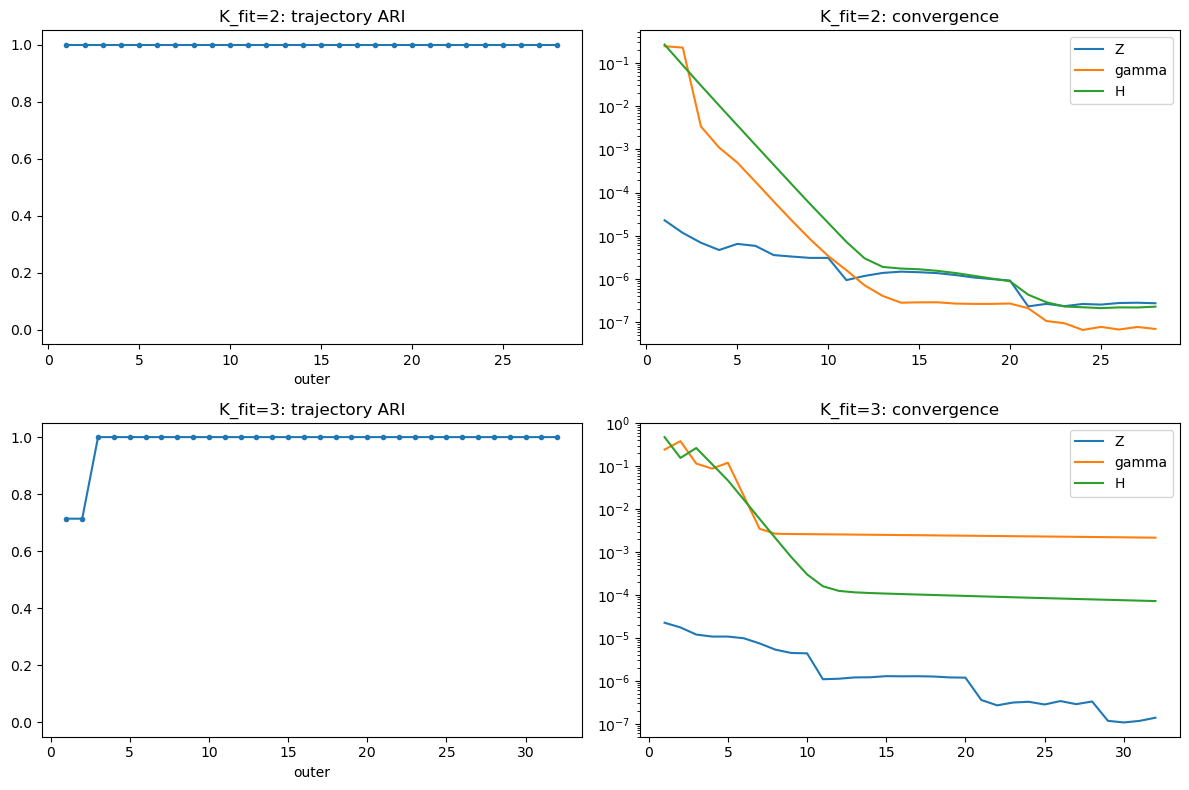

In [12]:

fig,axes=plt.subplots(2,2,figsize=(12,8))
for row,k in enumerate([2,3]):
    tr=results[k]["trace"]
    axes[row,0].plot(tr["outer"],tr["ARI"],marker="o",ms=3)
    axes[row,0].set_title(f"K_fit={k}: trajectory ARI")
    axes[row,0].set_xlabel("outer"); axes[row,0].set_ylim(-.05,1.05)
    axes[row,1].plot(tr["outer"],tr["z_rel"],label="Z")
    axes[row,1].plot(tr["outer"],tr["gamma_rel"],label="gamma")
    axes[row,1].plot(tr["outer"],tr["H_rel"],label="H")
    axes[row,1].set_yscale("log"); axes[row,1].set_title(f"K_fit={k}: convergence")
    axes[row,1].legend()
plt.tight_layout(); plt.show()


## 11. Graph and responsibility figures

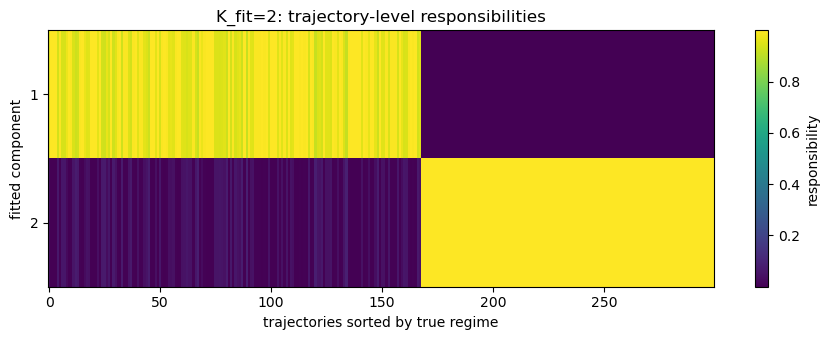

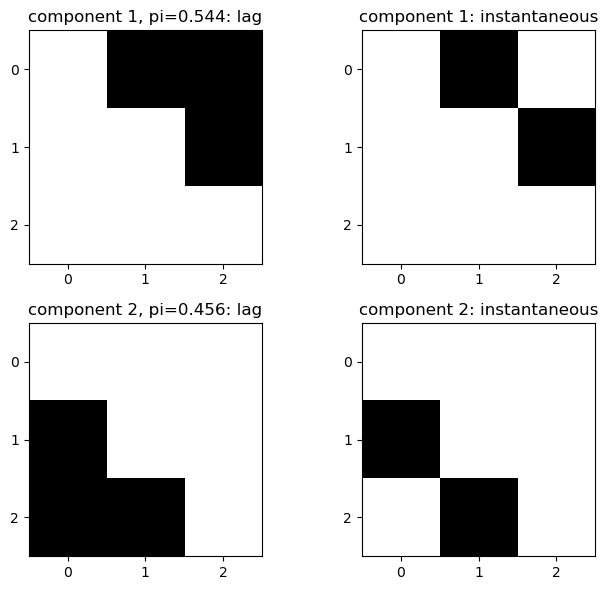

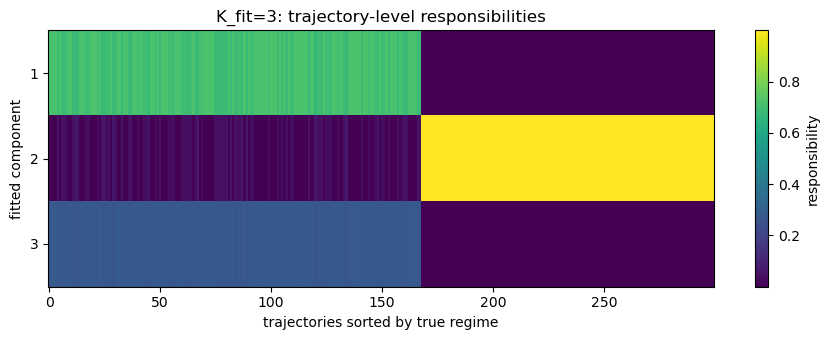

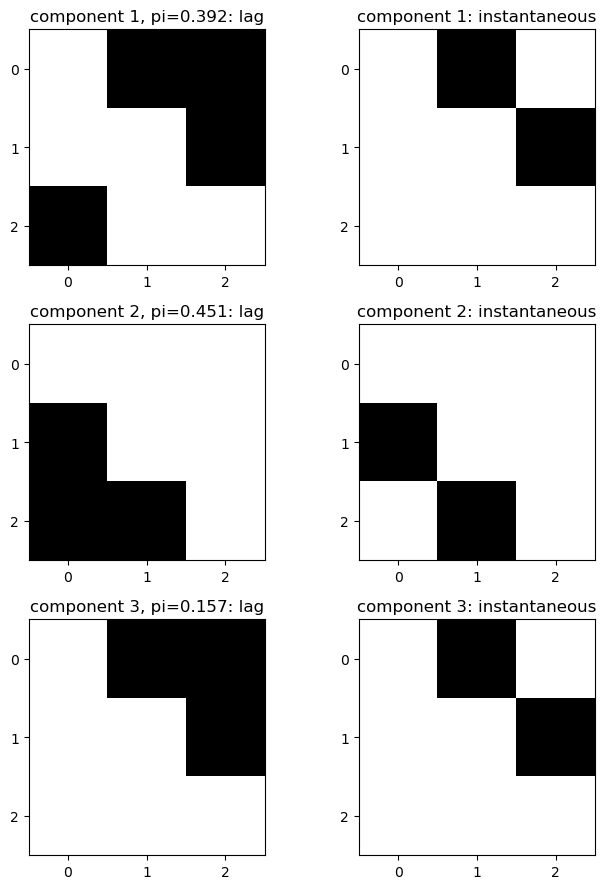

In [13]:

for k,res in results.items():
    order=np.argsort(R_true)
    plt.figure(figsize=(9,3.5))
    plt.imshow(res["gamma"][order].T,aspect="auto",interpolation="nearest")
    plt.colorbar(label="responsibility")
    plt.yticks(np.arange(k),np.arange(1,k+1))
    plt.xlabel("trajectories sorted by true regime")
    plt.ylabel("fitted component")
    plt.title(f"K_fit={k}: trajectory-level responsibilities")
    plt.tight_layout(); plt.show()

    fig,axes=plt.subplots(k,2,figsize=(7,3*k))
    if k==1: axes=np.array([axes])
    for r,j in enumerate(res["pairs"]):
        Gl,Gi=GRAPH_PAIRS[int(j)]
        axes[r,0].imshow(Gl,vmin=0,vmax=1,cmap="Greys")
        axes[r,0].set_title(f"component {r+1}, pi={res['pi'][r]:.3f}: lag")
        axes[r,1].imshow(Gi,vmin=0,vmax=1,cmap="Greys")
        axes[r,1].set_title(f"component {r+1}: instantaneous")
        for ax in axes[r]:
            ax.set_xticks(range(A)); ax.set_yticks(range(A))
    plt.tight_layout(); plt.show()


## 12. Coordinate and mechanism diagnostics

In [14]:

def coord_r2(Z):
    out=[]
    for a in range(A):
        x=Z[val_idx,:,a].reshape(-1); y=Z_true_np[val_idx,:,a].reshape(-1)
        Xd=np.c_[x,np.ones(len(x))]; b=np.linalg.lstsq(Xd,y,rcond=None)[0]
        out.append(r2_score(y,Xd@b))
    return np.array(out)

def mechanism_r2_by_component(res):
    rows=[]
    Z=res["state"]["Z"]
    hard=res["gamma"].argmax(1)
    for r,j in enumerate(res["pairs"]):
        ids=val_idx[hard[val_idx]==r]
        if len(ids)<2: continue
        Gl,Gi=GRAPH_PAIRS[int(j)]
        for a in range(A):
            obs=I_np[ids,a]<.5
            if obs.sum()==0: continue
            zp=Z[ids,:-1][obs].reshape(-1,A); zc=Z[ids,1:][obs].reshape(-1,A)
            h=res["Hs"][r][a]
            pred=h["beta_full"][0]+h["beta_full"][1]*zp[:,a]
            for q in range(A):
                pred+=h["beta_full"][2+q]*Gl[q,a]*np.tanh(zp[:,q])
                pred+=h["beta_full"][2+A+q]*Gi[q,a]*np.tanh(zc[:,q])
            rows.append({"component":r+1,"child":a+1,"validation R2":r2_score(zc[:,a],pred)})
    return pd.DataFrame(rows)

for k,res in results.items():
    print("K_fit",k,"coordinate R2",np.round(coord_r2(res["state"]["Z"]),4))
    display(mechanism_r2_by_component(res))


K_fit 2 coordinate R2 [1.    1.    0.998]


,component,child,validation R2
0,1,1,0.358009
1,1,2,0.990991
2,1,3,0.912433
3,2,1,0.707678
4,2,2,0.490273
5,2,3,0.209111


K_fit 3 coordinate R2 [1.    1.    0.998]


,component,child,validation R2
0,1,1,0.357803
1,1,2,0.990951
2,1,3,0.912737
3,2,1,0.708586
4,2,2,0.491215
5,2,3,0.211014
